In [1]:
# Load packages
import sys
import numpy as np
import pandas as pd
import scipy
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 400 #high res figures
import matplotlib.pyplot as plt
%matplotlib inline
import sklearn
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import shap
import pickle

In [2]:
with open('Activity_6_01_data.pkl', 'rb') as f:
    features_response, X_train_all, y_train_all, X_test_all,\
    y_test_all = pickle.load(f)

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train_2, X_val_2, y_train_2, y_val_2 = \
train_test_split(X_train_all, y_train_all, test_size=0.2, random_state=24)

In [5]:
xgb_model_4 = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=0,
    learning_rate=0.1,
    verbosity=1,
    objective='binary:logistic',
    n_jobs=-1,
    tree_method='hist',
    grow_policy='lossguide',
    eval_metric='auc',
    early_stopping_rounds=30)
# n_estimators=1000：总共训练1000棵树
# tree_method='hist'：使用直方图算法。它会将连续特征分桶，大幅减少计算量，是处理大数据的首选。
# Lossguide 模式 (Leaf-wise)：max_depth=0是说为了让模型完全由 max_leaves（最大叶子数）来控制树的大小，而不是被深度限制住

In [6]:
max_leaves_values = list(range(5,205,5))
print(max_leaves_values[:5])
print(max_leaves_values[-5:])

[5, 10, 15, 20, 25]
[180, 185, 190, 195, 200]


In [7]:
eval_set_2 = [(X_train_2, y_train_2), (X_val_2, y_val_2)]

In [8]:
%%time
val_aucs = []
for max_leaves in max_leaves_values:
    #Set parameter and fit model
    xgb_model_4.set_params(**{'max_leaves':max_leaves})
    xgb_model_4.fit(X_train_2, y_train_2, eval_set=eval_set_2,
                  verbose=False)
    
    #Get validation score
    val_set_pred_proba = xgb_model_4.predict_proba(X_val_2)[:,1]
    val_aucs.append(roc_auc_score(y_val_2, val_set_pred_proba))

CPU times: user 38 s, sys: 1min 4s, total: 1min 42s
Wall time: 47.3 s


In [9]:
max_leaves_df_2 = \
pd.DataFrame({'Max leaves':max_leaves_values,
              'Validation AUC':val_aucs})

<Axes: xlabel='Max leaves'>

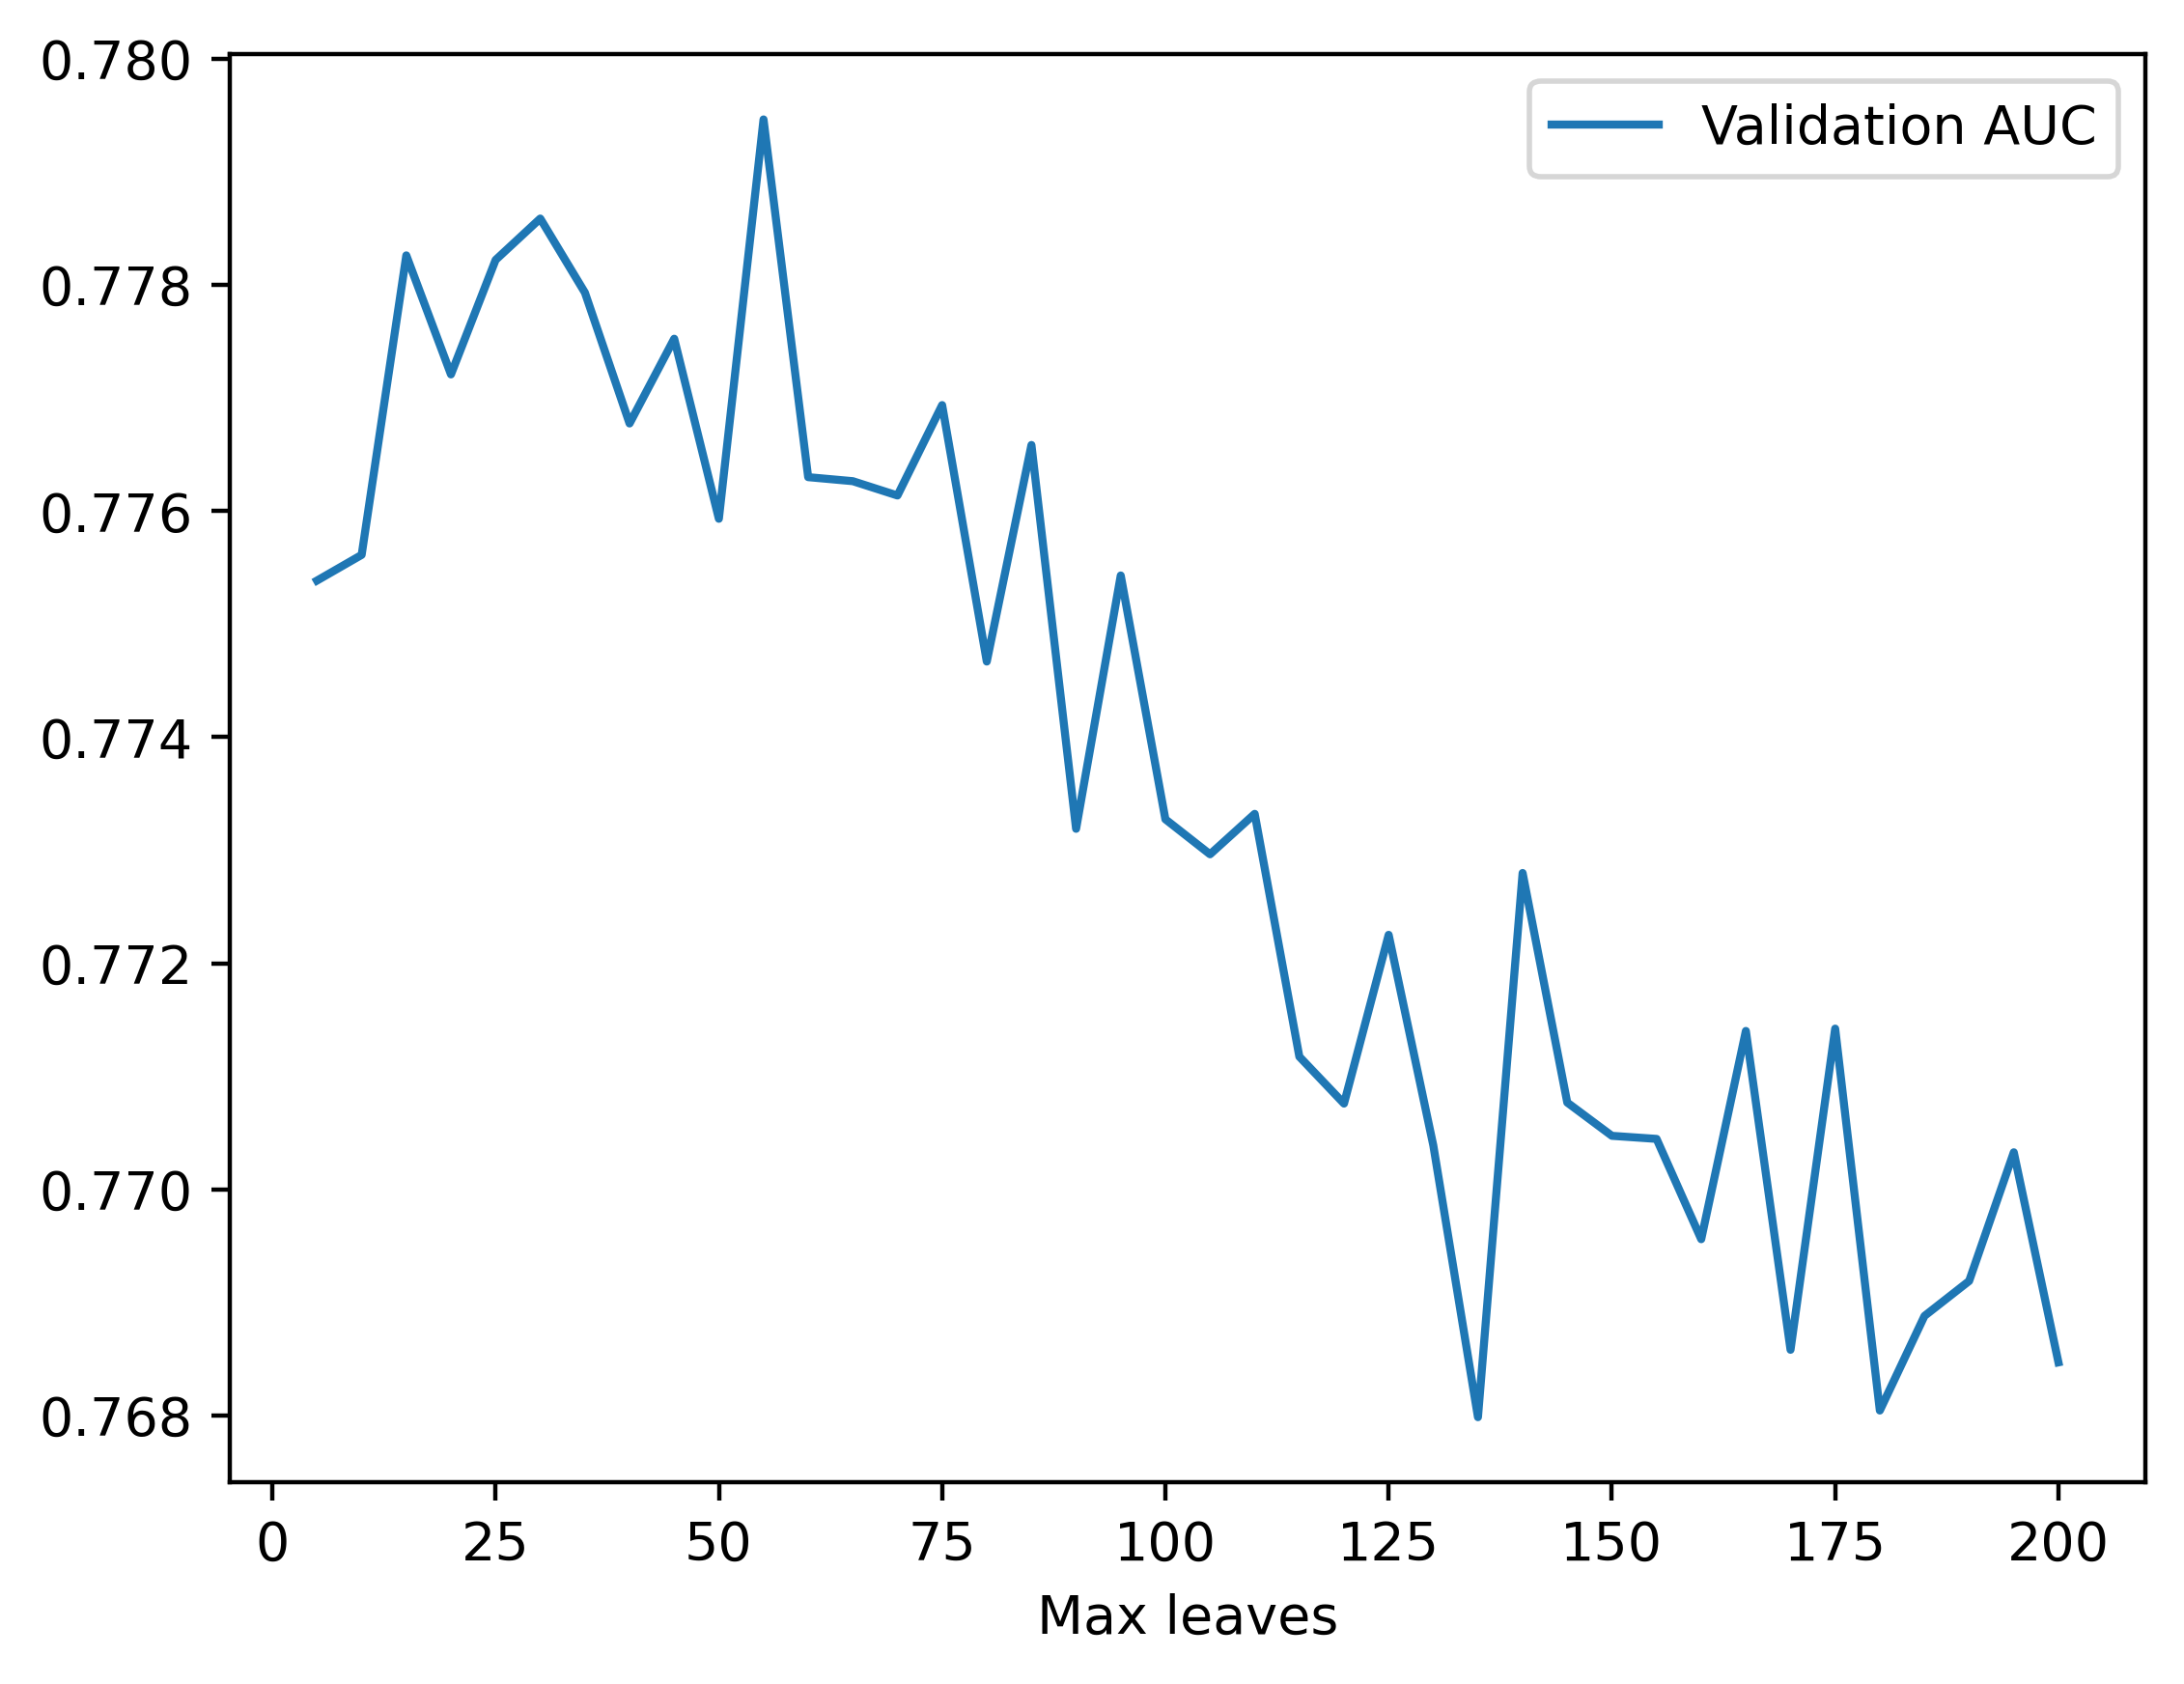

In [10]:
mpl.rcParams['figure.dpi'] = 400
max_leaves_df_2.set_index('Max leaves').plot()

Although the relationship is somewhat noisy, we see that in general, lower
values of max_leaves result in a higher validation set ROC AUC. This is
because limiting the complexity of trees by allowing fewer leaves results in less
overfitting, and increases the validation set score.

In [11]:
max_auc_2 = max_leaves_df_2['Validation AUC'].max()
max_auc_2
# 0.7785918508068121 (learning rate 0.1)
# 0.7783846497029288 (learning rate 0.05)

0.7794630134226972

In [12]:
max_ix_2 = max_leaves_df_2['Validation AUC'] == max_auc_2
max_leaves_df_2[max_ix_2]

,Max leaves,Validation AUC
10,55,0.779463


In [13]:
# Retrain with optimal hyperparameter.

In [14]:
xgb_model_4.set_params(**{'max_leaves':55})
xgb_model_4.fit(X_train_2, y_train_2, eval_set=eval_set_2,
                  verbose=False)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=30,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              gamma=None, grow_policy='lossguide', importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=0, max_leaves=55,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=-1,
              num_parallel_tree=None, random_state=None, ...)

In [16]:
X_val_2_df = pd.DataFrame(data=X_val_2, columns=features_response[:-1])
X_val_2_df.head(5)

,LIMIT_BAL,EDUCATION,MARRIAGE,AGE,PAY_1,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,50000.0,2.0,1.0,39.0,-1.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0,390.0
1,400000.0,1.0,2.0,29.0,0.0,7191.0,8856.0,6181.0,7859.0,4899.0,1466.0,2000.0,1500.0,2000.0,1000.0,500.0,1000.0
2,200000.0,2.0,2.0,26.0,0.0,22737.0,12169.0,14328.0,16222.0,9915.0,11226.0,3000.0,6000.0,3000.0,2003.0,3101.0,530.0
3,280000.0,1.0,2.0,38.0,-1.0,17878.0,14011.0,30079.0,13139.0,13989.0,15559.0,2000.0,30000.0,14000.0,1000.0,16000.0,0.0
4,80000.0,3.0,1.0,65.0,0.0,80260.0,82116.0,80299.0,81416.0,81617.0,81607.0,3750.0,3520.0,3069.0,3271.0,3262.0,3237.0


SHAP Summary

In [23]:
%time explainer_2 = shap.explainers.Tree(xgb_model_4, data=X_val_2_df)

CPU times: user 22.1 ms, sys: 2.47 ms, total: 24.6 ms
Wall time: 24.2 ms


In [24]:
%time shap_values_2 = explainer_2(X_val_2_df)

CPU times: user 6.14 s, sys: 18.3 ms, total: 6.16 s
Wall time: 6.15 s


In [25]:
shap_values_2.values.shape

(4750, 17)

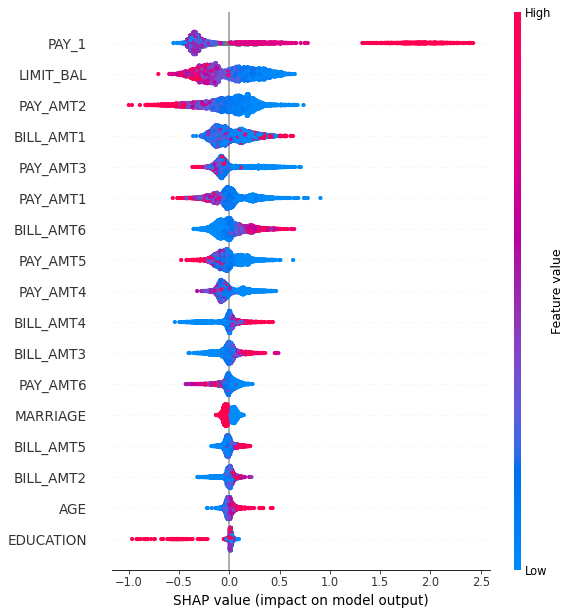

CPU times: user 316 ms, sys: 3.62 ms, total: 319 ms
Wall time: 319 ms


In [26]:
%%time
mpl.rcParams['figure.dpi'] = 75
shap.summary_plot(shap_values_2.values, X_val_2_df)

1. we can see that the most important features in the XGBoost
model are pay_1, same as those in the random forest model we
explored previously.
2. SHAP Value > 0 means push the model prediction to "positive", meaning default.
3. color red means high feature value. high pay_1 value has a big >0 shap value, meaning
   如果一个人最近延迟还款很严重，模型会强烈倾向于判定他会违约
p.s.PAY_1–PAY_6: A record of past payments. Past monthly payments, recorded
from April to September, are stored in these columns.
PAY_1 represents the repayment status in September; PAY_2 is the repayment
status in August; and so on up to PAY_6, which represents the repayment status
in April. The measurement scale for the repayment status is as follows: -1 = pay duly; 1 =
payment delay for 1 month; 2 = payment delay for 2 months; and so on up to 8 =
payment delay for 8 months; 9 = payment delay for 9 months and above. 

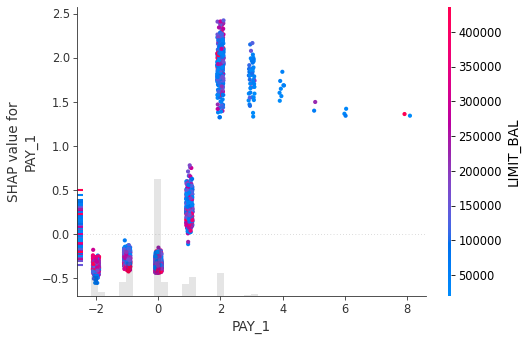

In [27]:
shap.plots.scatter(shap_values_2[:,'PAY_1'],color=shap_values_2)

limit_bal has the strongest interaction with pay_1.  We can see that for values of
pay_1 > 0(payment delay), if the limit_bal was particularly low(blue dots), this leads to more positive SHAP
values, meaning an increased risk of default. 

In [29]:
with open('xgb_model_w_data.pkl', 'wb') as f:
 pickle.dump([features_response, X_train_all, y_train_all,X_test_all, y_test_all,xgb_model_4], f)